In [47]:
from typing import Optional, Dict
from transformers import pipeline

In [49]:

model_name = "facebook/bart-large-mnli"  
device = -1  

classifier = pipeline(
    "zero-shot-classification",
    model=model_name,
    device=device
)

labels = [
    "high urgency message requiring immediate action or strict deadline",
    "moderate urgency message that should be handled soon but not immediately",
    "low urgency informational message with no time pressure"
]

label_map = {
    labels[0]: "high",
    labels[1]: "medium",
    labels[2]: "low"
}

print("Classifier initialized successfully!")
print(f"Using model: {model_name}")
print(f"Labels: {label_map}")

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Classifier initialized successfully!
Using model: facebook/bart-large-mnli
Labels: {'high urgency message requiring immediate action or strict deadline': 'high', 'moderate urgency message that should be handled soon but not immediately': 'medium', 'low urgency informational message with no time pressure': 'low'}


In [9]:
def classify_urgency(text: str, category: Optional[str] = None) -> Dict:
    """
    Classify a single message using zero-shot learning
    
    Args:
        text: The message text to classify
        category: Optional category context (e.g., "IT Support", "Customer Service")
    
    Returns:
        Dictionary with urgency level and confidence score
    """
   
    if category:
        text_with_context = f"This is a {category} message: {text}"
    else:
        text_with_context = text
    
    result = classifier(
        text_with_context,
        candidate_labels=labels,
        hypothesis_template="This message has {}.",
        multi_label=False
    )
    
    label = result["labels"][0]
    score = float(result["scores"][0])
    urgency = label_map[label]
    
    return {
        "urgency": urgency,
        "confidence": round(score, 3),
        "full_results": {
            "labels": result["labels"],
            "scores": [round(s, 3) for s in result["scores"]]
        }  
    }

In [10]:

test_messages = [
    {
        "text": "The server is down and customers are complaining! We need to fix this NOW!",
        "category": "IT Support"
    },
    {
        "text": "Could you please review this document when you have time? No rush.",
        "category": "General"
    },
    {
        "text": "Meeting scheduled for next week. Let me know if you can attend.",
        "category": "Calendar"
    },
    {
        "text": "URGENT: Please submit your report by 5pm today, it's required for the board meeting.",
        "category": "Work"
    }
]

for i, test in enumerate(test_messages, 1):
    result = classify_urgency(test["text"], test["category"])
    print(f"\n--- Test {i} ---")
    print(f"Message: {test['text']}")
    print(f"Category: {test['category']}")
    print(f"Result: {result['urgency']} (confidence: {result['confidence']})")
    print(f"All scores: {result['full_results']}")


--- Test 1 ---
Message: The server is down and customers are complaining! We need to fix this NOW!
Category: IT Support
Result: high (confidence: 0.838)
All scores: {'labels': ['high urgency message requiring immediate action or strict deadline', 'moderate urgency message that should be handled soon but not immediately', 'low urgency informational message with no time pressure'], 'scores': [0.838, 0.123, 0.039]}

--- Test 2 ---
Message: Could you please review this document when you have time? No rush.
Category: General
Result: low (confidence: 0.988)
All scores: {'labels': ['low urgency informational message with no time pressure', 'moderate urgency message that should be handled soon but not immediately', 'high urgency message requiring immediate action or strict deadline'], 'scores': [0.988, 0.011, 0.002]}

--- Test 3 ---
Message: Meeting scheduled for next week. Let me know if you can attend.
Category: Calendar
Result: low (confidence: 0.54)
All scores: {'labels': ['low urgency in

In [11]:
def classify_batchs(messages: list, category: Optional[str] = None) -> list:
    """
    Classify multiple messages
    
    Args:
        messages: List of message texts
        category: Optional category to apply to all messages
    
    Returns:
        List of results
    """
    results = []
    for msg in messages:
        result = classify_urgency(msg, category)
        results.append({
            "text": msg,
            "result": result
        })
    return results

batch_messages = [
    "The printer is jammed and we need to print contracts for a client meeting in 1 hour",
    "Just a reminder about the team lunch tomorrow",
    "CRITICAL: Payment gateway is down, transactions failing!"
]

batch_results = classify_batchs(batch_messages, category="Office")

print("\n=== Batch Classification Results ===")
for item in batch_results:
    print(f"\nMessage: {item['text']}")
    print(f"Urgency: {item['result']['urgency']} (confidence: {item['result']['confidence']})")


=== Batch Classification Results ===

Message: The printer is jammed and we need to print contracts for a client meeting in 1 hour
Urgency: high (confidence: 0.722)

Message: Just a reminder about the team lunch tomorrow
Urgency: low (confidence: 0.9)

Message: CRITICAL: Payment gateway is down, transactions failing!
Urgency: high (confidence: 0.854)


dataset loading



In [12]:
import pandas as pd
import warnings

df= pd.read_csv("train_preprocess.csv")


In [13]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    batch_df = (
        df.groupby("urgency", group_keys=False)
               .apply(lambda x: x.sample(10, random_state=42))
               .reset_index(drop=True)
    )

In [14]:
print("Selected rows:")
print(batch_df[["text", "category", "urgency"]])

Selected rows:
                                                 text      category urgency
0   paypal refund notification rp-3344 immediate a...          spam    High
1   r programming reply python error revised rules...         forum    High
2   verification required 799237 token 417380 expi...   verify_code    High
3   refund confirmation r-2873-uk package could no...          spam    High
4   last chance black friday july celebrate 70 off...    promotions    High
5   identity verification required 776979 token 32...   verify_code    High
6   final notice facebook end samsung galaxy logge...          spam    High
7   google investment opportunity 500 roi immediat...          spam    High
8   moderator thread processed revised rules effec...         forum    High
9   new message secret admirer dear winner, email ...          spam    High
10  amazon password expiration invoice inv-2345 50...          spam     Low
11  safety recall model xz-240 new features securi...       updates     L

In [15]:
def classify_batch(df: pd.DataFrame) -> pd.DataFrame:
    results = []
    df = df.copy()
    for _, row in df.iterrows():
        result = classify_urgency(row["text"], row["category"])
        results.append({
            "text"          : row["text"],
            "category"      : row["category"],
            "true_urgency"  : row["urgency"],
            "pred_urgency"  : result["urgency"],
            "confidence"    : result.get("confidence", "N/A"),
            "correct"       : result["urgency"].lower() == row["urgency"].lower()
        })
  
    df['pred_urgency'] = [r['pred_urgency'] for r in results]
    df['confidence'] = [r['confidence'] for r in results]
    return df

In [16]:
batch_results = classify_batch(batch_df)


In [17]:
batch_df.head(20)



,body,text,category,urgency
0,Immediate action required! Your subscription p...,paypal refund notification rp-3344 immediate a...,spam,High
1,Revised rules effective immediately. Key chang...,r programming reply python error revised rules...,forum,High
2,Token: 417380 expires at 16:20 PST. For suppor...,verification required 799237 token 417380 expi...,verify_code,High
3,Your package couldn't be delivered. Tracking# ...,refund confirmation r-2873-uk package could no...,spam,High
4,Celebrate with 70% off entire purchase. Valid ...,last chance black friday july celebrate 70 off...,promotions,High
5,Token: 321591 expires at 14:30 GMT. For suppor...,identity verification required 776979 token 32...,verify_code,High
6,Samsung Galaxy logged in 2hrs minutes ago. Ver...,final notice facebook end samsung galaxy logge...,spam,High
7,Immediate action required! Your subscription p...,google investment opportunity 500 roi immediat...,spam,High
8,Revised rules effective immediately. Key chang...,moderator thread processed revised rules effec...,forum,High
9,"Dear Winner, Your email won $1000 in our annua...","new message secret admirer dear winner, email ...",spam,High


In [18]:
test=df.head(20)


In [19]:
test=classify_batch(test)

In [20]:
test.head()

,body,text,category,urgency,pred_urgency,confidence
0,"As our loyal customer, get exclusive $60 off $...",anniversary special buy one get one free loyal...,promotions,Low,low,0.737
1,Your $5000 refund is processed. Claim: bit.ly/...,amazon used new device 5000 refund processed. ...,spam,Low,medium,0.584
2,"Hi, following up about your Google application...","google inquiry hi, following up google applica...",spam,Low,low,0.443
3,Cross-cultural ceremony design. Join: virtualr...,digital ritual experience creation cross-cultu...,social_media,Low,low,0.444
4,"Trending: ""cooking"" (258 comments). View: supp...",post moved programming help trending cooking 2...,forum,Low,low,0.473


full dataset


In [21]:
def classify_full(df: pd.DataFrame, max_workers: int = 8) -> pd.DataFrame:
    from concurrent.futures import ThreadPoolExecutor, as_completed
    from tqdm import tqdm

    df = df.copy().reset_index(drop=True)
    df["pred_urgency"] = None
    df["confidence"]   = None
    df["correct"]      = None

    def classify_single(idx, row):
        try:
            result = classify_urgency(row["text"], row["category"])
            return idx, result["urgency"], result.get("confidence", "N/A")
        except Exception:
            return idx, "error", 0.0

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {
            executor.submit(classify_single, idx, row): idx
            for idx, row in df.iterrows()
        }
        for future in tqdm(as_completed(futures), total=len(df), desc="Classifying"):
            idx, pred, conf = future.result()
            df.at[idx, "pred_urgency"] = pred
            df.at[idx, "confidence"]   = conf

    df["correct"] = df.apply(
        lambda row: str(row["pred_urgency"]).lower() == str(row["urgency"]).lower(),
        axis=1
    )
    return df



In [22]:


df_full = pd.read_csv("train_preprocess.csv")

result_df = classify_full(df_full, max_workers=8)


Classifying: 100%|██████████| 10073/10073 [1:38:42<00:00,  1.70it/s] 


In [23]:
result_df.head()

,body,text,category,urgency,pred_urgency,confidence,correct
0,"As our loyal customer, get exclusive $60 off $...",anniversary special buy one get one free loyal...,promotions,Low,low,0.737,True
1,Your $5000 refund is processed. Claim: bit.ly/...,amazon used new device 5000 refund processed. ...,spam,Low,medium,0.584,False
2,"Hi, following up about your Google application...","google inquiry hi, following up google applica...",spam,Low,low,0.443,True
3,Cross-cultural ceremony design. Join: virtualr...,digital ritual experience creation cross-cultu...,social_media,Low,low,0.444,True
4,"Trending: ""cooking"" (258 comments). View: supp...",post moved programming help trending cooking 2...,forum,Low,low,0.473,True


In [42]:
result_df.to_csv("zero-shot.csv", index=False)

Classification Report

In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [35]:
urg=pd.read_csv("urgency_rule.csv")

In [36]:
y_true = urg["urgency"].str.lower().str.strip()
y_pred = result_df["pred_urgency"].str.lower().str.strip()

In [44]:

from sklearn.metrics import accuracy_score, classification_report

In [45]:
print(f"Accuracy : {accuracy_score(y_true, y_pred):.2%}")

Accuracy : 54.16%


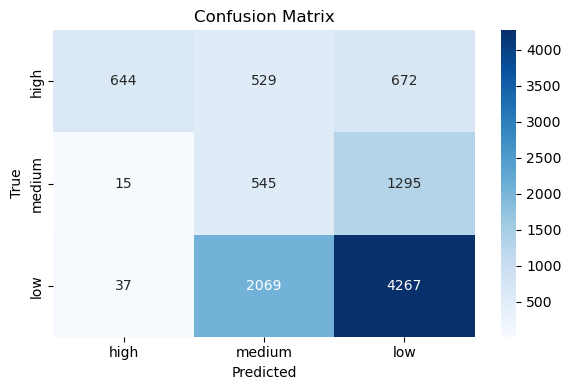

In [37]:
cm = confusion_matrix(y_true, y_pred, labels=["high", "medium", "low"])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["high", "medium", "low"],
            yticklabels=["high", "medium", "low"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [38]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

        high       0.93      0.35      0.51      1845
         low       0.68      0.67      0.68      6373
      medium       0.17      0.29      0.22      1855

    accuracy                           0.54     10073
   macro avg       0.59      0.44      0.47     10073
weighted avg       0.63      0.54      0.56     10073



In [39]:
category_urgency = result_df.groupby(["category", "pred_urgency"]).size().unstack(fill_value=0)
print(category_urgency)


pred_urgency  high   low  medium
category                        
forum          111   914     547
promotions      23  1667      75
social_media     2   583    1104
spam           376   606     737
updates         34  1305     220
verify_code    150  1159     460


In [40]:
category_urgency = result_df.groupby(["category", "urgency"]).size().unstack(fill_value=0)
print(category_urgency)


urgency       High   Low  Medium
category                        
forum          123  1368      81
promotions     327  1431       7
social_media     4  1525     160
spam           661   881     177
updates        105  1042     412
verify_code    504   308     957


In [53]:
classifier.model.save_pretrained("./zeroshot_model")
classifier.tokenizer.save_pretrained("./zeroshot_model")
print("Model saved to ./zeroshot_model")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./zeroshot_model
